# Avaliação de LLMs em Editais Públicos — Avaliação Final Corrigida

Este notebook complementa o `exploracao_avaliacoes_llms.ipynb`.  
A diferença central é a **`avaliacao_final`**: quando GPT e Opus convergiram, usa o valor comum; quando divergiram (92 casos), usa o **árbitro humano** registrado em `divergentes.xlsx`.

Arquivos esperados na mesma pasta:
- `df_avaliacoes.xlsx` — 1.350 linhas com avaliações GPT e Opus
- `df_metricas.xlsx` — 2.700 linhas com métricas operacionais
- `divergentes.xlsx` — 92 casos divergentes com avaliação humana


## 1. Configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.metrics import cohen_kappa_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "font.size": 10, "axes.titleweight": "bold", "axes.titlesize": 12,
})

PALETA_PROVEDOR  = {"anthropic": "#D97757", "openai": "#10A37F", "deepseek": "#4D6BFE"}
PALETA_AVALIADOR = {"gpt": "#10A37F", "opus": "#D97757", "humano": "#8E44AD"}
CORES_NOTA       = {0.0: "#E74C3C", 0.5: "#F39C12", 1.0: "#2ECC71"}


## 2. Carregamento e construção da `avaliacao_final`

In [2]:
PATH = Path(".")   # mesmo diretório do notebook

df_av  = pd.read_excel(PATH / "df_avaliacoes.xlsx")
df_me  = pd.read_excel(PATH / "df_metricas.xlsx")
df_div = pd.read_excel(PATH / "divergentes_human_eval.xlsx")

print(f"df_avaliacoes : {df_av.shape[0]:>5} linhas × {df_av.shape[1]} colunas")
print(f"df_metricas   : {df_me.shape[0]:>5} linhas × {df_me.shape[1]} colunas")
print(f"df_divergentes: {df_div.shape[0]:>5} linhas × {df_div.shape[1]} colunas")
print(f"\nModelos : {sorted(df_av['modelo'].unique())}")
print(f"Editais : {sorted(df_av['edital'].unique())}")
print(f"Categorias: {sorted(df_av['categoria'].unique())}")


df_avaliacoes :  1350 linhas × 12 colunas
df_metricas   :  2700 linhas × 17 colunas
df_divergentes:    92 linhas × 12 colunas

Modelos : ['claude-haiku-4-5', 'claude-opus-4-7', 'claude-sonnet-4-6', 'deepseek-v4-flash', 'deepseek-v4-pro', 'gpt-4o-mini', 'gpt-5.4', 'gpt-5.4-mini', 'gpt-5.5']
Editais : ['bndes', 'cvm', 'petrobras']
Categorias: ['Dados sobre Procedimentos', 'Dados sobre a Prova', 'Dados sobre as inscrições', 'Dados sobre o Cargo', 'Dados sobre o Concurso']


In [6]:
df_div['Modelo Correto'].value_counts()

Modelo Correto
gpt     63
opus    29
Name: count, dtype: int64

In [3]:
# Extrair edital e modelo da coluna 'pasta'  (formato: '{edital}_{modelo}')
df_div[["edital_h","modelo_h"]] = df_div["pasta"].str.split("_", n=1, expand=True)

lookup = (df_div[["edital_h","modelo_h","id","Avaliação Humana","Modelo Correto"]]
          .rename(columns={"edital_h":"edital","modelo_h":"modelo",
                           "Avaliação Humana":"avaliacao_humana",
                           "Modelo Correto":"modelo_correto"}))

df_av = df_av.merge(lookup, on=["edital","modelo","id"], how="left")

# avaliacao_final: valor comum quando converge, humano quando diverge
df_av["avaliacao_final"] = np.where(
    df_av["convergencia"],
    df_av["avaliacao_gpt"],          # ambas iguais — qualquer uma serve
    df_av["avaliacao_humana"]
)

# nota_consenso (média simples, para comparar depois)
df_av["nota_consenso"] = (df_av["avaliacao_gpt"] + df_av["avaliacao_opus"]) / 2

n_div = (~df_av["convergencia"]).sum()
n_ok  = df_av[~df_av["convergencia"] & df_av["avaliacao_final"].notna()].shape[0]
print(f"Divergências totais:              {n_div}")
print(f"Com arbitragem humana aplicada:   {n_ok}  ({'OK' if n_ok == n_div else 'ATENÇÃO — faltam casos'})")
print(f"Nulls em avaliacao_final:         {df_av['avaliacao_final'].isna().sum()}")


Divergências totais:              92
Com arbitragem humana aplicada:   92  (OK)
Nulls em avaliacao_final:         0


## 3. Impacto da arbitragem humana

### 3.1 O que mudou após a correção?

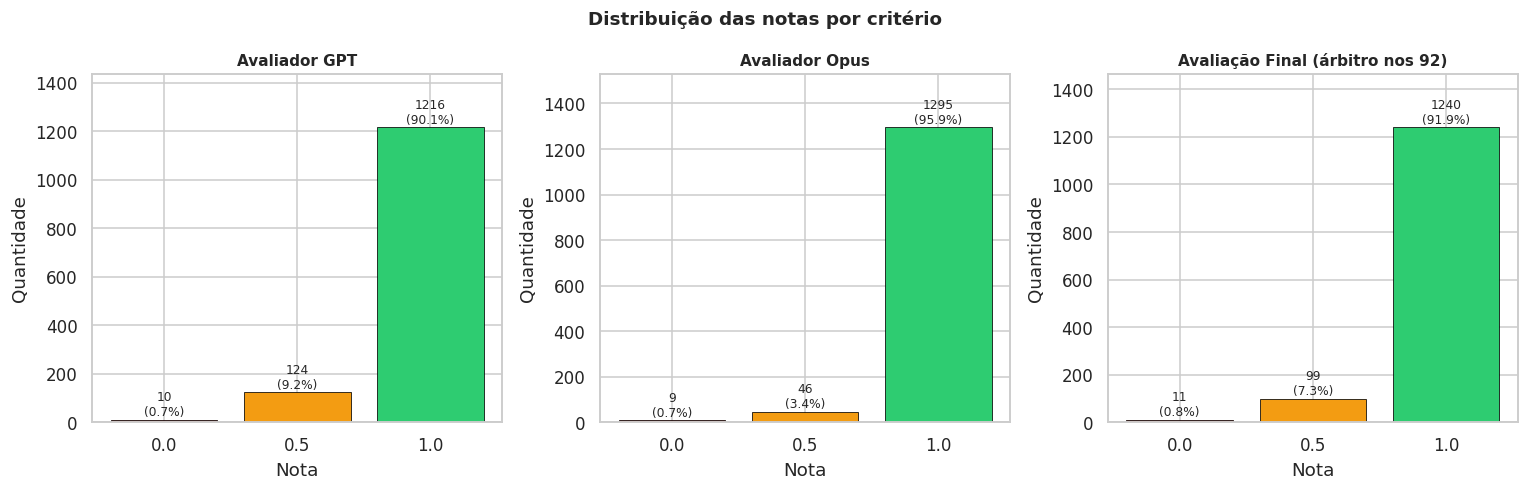

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, col, titulo in zip(axes,
        ["avaliacao_gpt", "avaliacao_opus", "avaliacao_final"],
        ["Avaliador GPT", "Avaliador Opus", "Avaliação Final (árbitro nos 92)"]):
    cnt = df_av[col].value_counts().sort_index()
    bars = ax.bar(cnt.index.astype(str), cnt.values,
                  color=[CORES_NOTA[k] for k in cnt.index],
                  edgecolor="black", linewidth=0.5)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("Nota")
    ax.set_ylabel("Quantidade")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 5,
                f"{int(h)}\n({h/len(df_av)*100:.1f}%)",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, cnt.max() * 1.18)

plt.suptitle("Distribuição das notas por critério", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### 3.2 Direção das mudanças nas 92 divergências

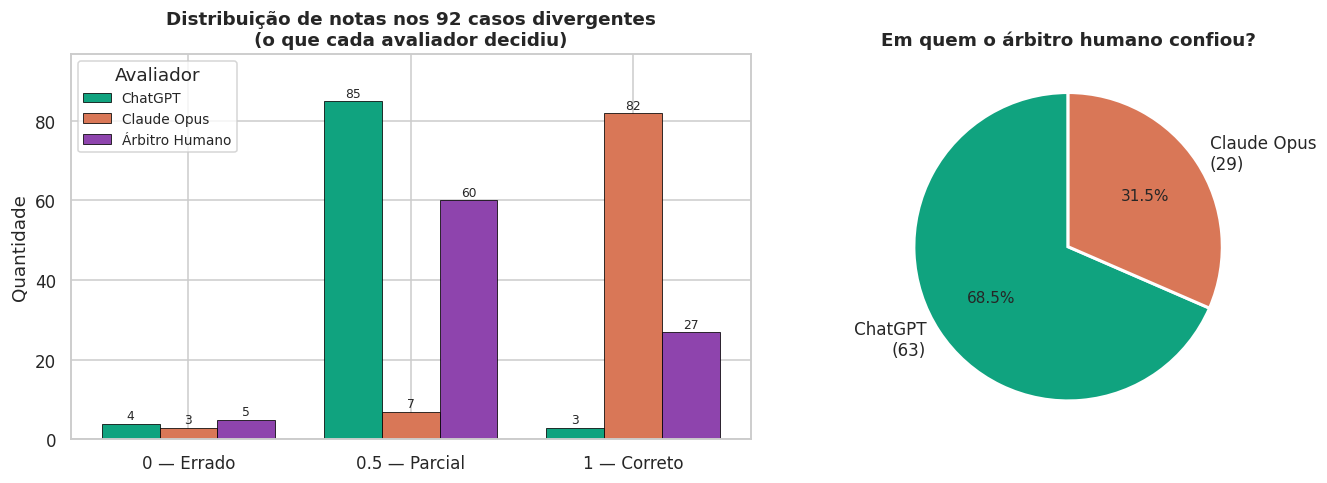

Humano concordou com ChatGPT:    63
Humano concordou com Claude Opus: 29


In [8]:
df_dv = df_av[~df_av["convergencia"]].copy()

NOMES_JUIZ = {"gpt": "ChatGPT", "opus": "Claude Opus"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Gráfico esquerdo: distribuição de notas nos 92 casos (por avaliador) ──
notas = [0.0, 0.5, 1.0]
x = np.arange(len(notas))
w = 0.26

cols_av = {
    "ChatGPT":       ("avaliacao_gpt",   PALETA_AVALIADOR["gpt"]),
    "Claude Opus":   ("avaliacao_opus",  PALETA_AVALIADOR["opus"]),
    "Árbitro Humano":("avaliacao_final", PALETA_AVALIADOR["humano"]),
}

for i, (label, (col, cor)) in enumerate(cols_av.items()):
    cnt = df_dv[col].value_counts().reindex(notas, fill_value=0)
    bars = axes[0].bar(x + (i - 1) * w, cnt.values,
                       w, label=label, color=cor,
                       edgecolor="black", linewidth=0.5)
    for bar, v in zip(bars, cnt.values):
        if v > 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                         str(v), ha="center", va="bottom", fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(["0 — Errado", "0.5 — Parcial", "1 — Correto"])
axes[0].set_ylabel("Quantidade")
axes[0].set_title("Distribuição de notas nos 92 casos divergentes\n(o que cada avaliador decidiu)")
axes[0].legend(title="Avaliador", fontsize=9)
axes[0].set_ylim(0, df_dv["avaliacao_opus"].value_counts().max() * 1.18)

# ── Gráfico direito: em quem o humano confiou ──
razao = df_dv["modelo_correto"].value_counts()
labels_pie = [f"{NOMES_JUIZ.get(k, k)}\n({v})" for k, v in razao.items()]
cores_r    = [PALETA_AVALIADOR.get(k, "#BDC3C7") for k in razao.index]

axes[1].pie(razao.values, labels=labels_pie,
            colors=cores_r, autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Em quem o árbitro humano confiou?")

plt.tight_layout()
plt.show()

print(f"Humano concordou com ChatGPT:    {razao.get('gpt',  0)}")
print(f"Humano concordou com Claude Opus: {razao.get('opus', 0)}")

### 3.3 Divergências por modelo (quais modelos geraram mais casos ambíguos?)

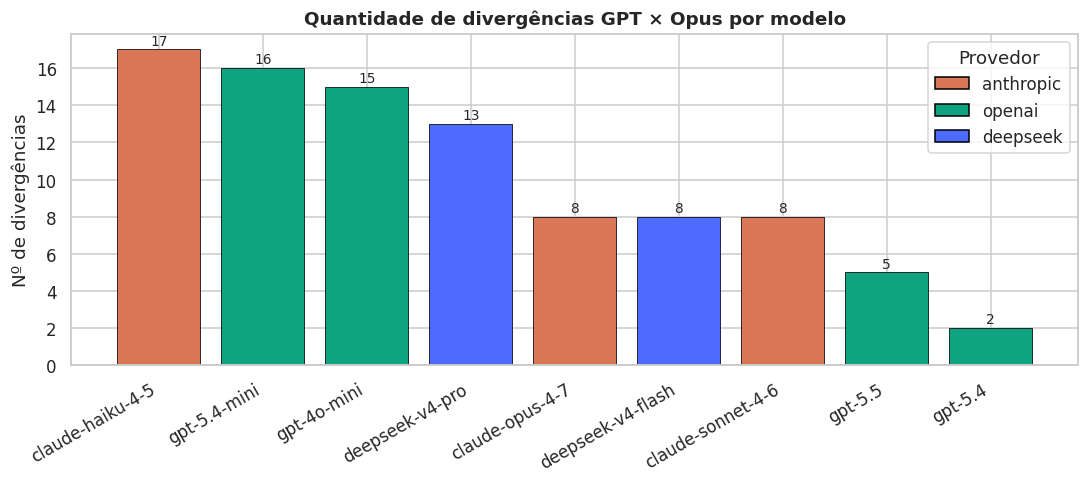

In [9]:
div_modelo = (~df_av["convergencia"]).groupby(df_av["modelo"]).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
cores = [PALETA_PROVEDOR[df_av[df_av["modelo"]==m]["provedor"].iloc[0]] for m in div_modelo.index]
bars = ax.bar(div_modelo.index, div_modelo.values,
              color=cores, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Nº de divergências")
ax.set_title("Quantidade de divergências GPT × Opus por modelo")
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), ha="right")
for bar, v in zip(bars, div_modelo.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(int(v)),
            ha="center", va="bottom", fontsize=9)

legend = [mpatches.Patch(facecolor=c, edgecolor="black", label=p)
          for p, c in PALETA_PROVEDOR.items()]
ax.legend(handles=legend, title="Provedor")
plt.tight_layout()
plt.show()


## 4. Concordância entre avaliadores

### 4.1 Convergência geral e Kappa

In [10]:
conv = df_av["convergencia"].mean()
gpt_int  = (df_av["avaliacao_gpt"]  * 2).astype(int)
opus_int = (df_av["avaliacao_opus"] * 2).astype(int)
kappa = cohen_kappa_score(gpt_int, opus_int)

print(f"Convergência global GPT × Opus:  {conv:.1%}  ({int(conv*len(df_av))} de {len(df_av)})")
print(f"Cohen's Kappa:                   {kappa:.3f}")
print("Interpretação: <0.20 fraca | 0.21-0.40 razoável | 0.41-0.60 moderada")
print("               0.61-0.80 substancial | >0.80 quase perfeita")


Convergência global GPT × Opus:  93.2%  (1258 de 1350)
Cohen's Kappa:                   0.487
Interpretação: <0.20 fraca | 0.21-0.40 razoável | 0.41-0.60 moderada
               0.61-0.80 substancial | >0.80 quase perfeita


### 4.2 Matriz de concordância GPT × Opus

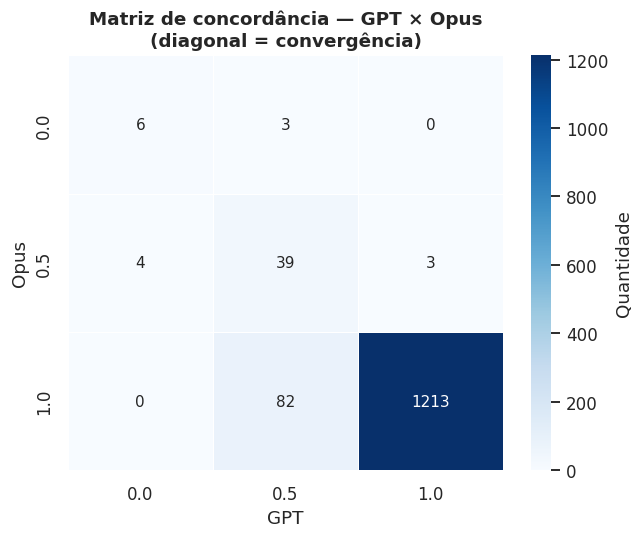

In [11]:
matriz = pd.crosstab(df_av["avaliacao_opus"], df_av["avaliacao_gpt"],
                    rownames=["Opus"], colnames=["GPT"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            cbar_kws={"label":"Quantidade"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Matriz de concordância — GPT × Opus\n(diagonal = convergência)")
plt.tight_layout()
plt.show()


### 4.3 Padrão das divergências: quem é mais generoso?

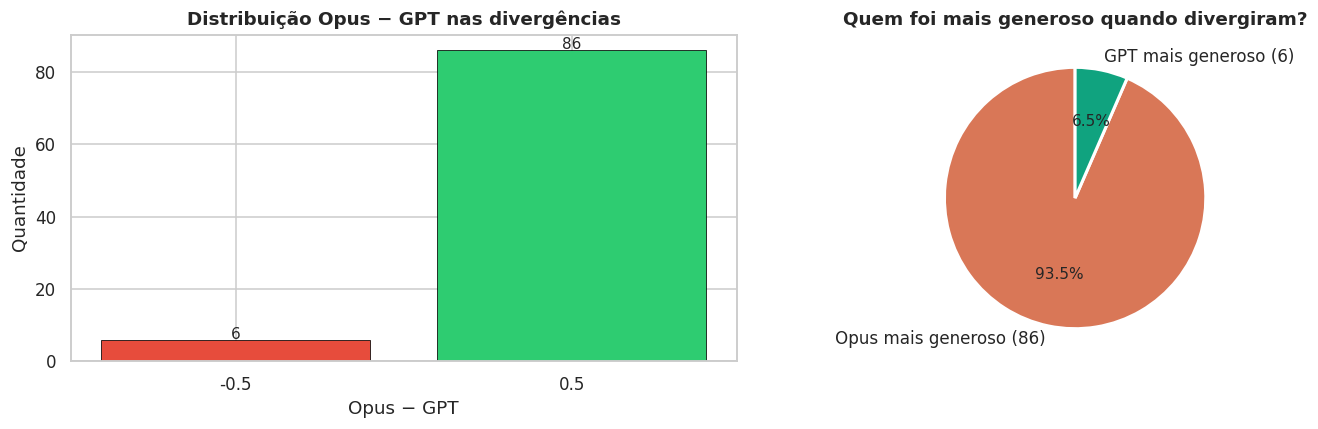


Média Opus − GPT: +0.435  (positivo = Opus mais generoso)


In [12]:
df_dv["dif_opus_gpt"] = df_dv["avaliacao_opus"] - df_dv["avaliacao_gpt"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cnt_dif = df_dv["dif_opus_gpt"].value_counts().sort_index()
cores_dif = ["#E74C3C" if x < 0 else "#2ECC71" for x in cnt_dif.index]
axes[0].bar(cnt_dif.index.astype(str), cnt_dif.values,
            color=cores_dif, edgecolor="black", linewidth=0.5)
axes[0].set_title("Distribuição Opus − GPT nas divergências")
axes[0].set_xlabel("Opus − GPT")
axes[0].set_ylabel("Quantidade")
for i, v in enumerate(cnt_dif.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=10)

mais_opus = (df_dv["dif_opus_gpt"] > 0).sum()
mais_gpt  = (df_dv["dif_opus_gpt"] < 0).sum()
axes[1].pie([mais_opus, mais_gpt],
            labels=[f"Opus mais generoso ({mais_opus})",
                    f"GPT mais generoso ({mais_gpt})"],
            colors=[PALETA_AVALIADOR["opus"], PALETA_AVALIADOR["gpt"]],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Quem foi mais generoso quando divergiram?")

plt.tight_layout()
plt.show()
print(f"\nMédia Opus − GPT: {df_dv['dif_opus_gpt'].mean():+.3f}  "
      f"(positivo = Opus mais generoso)")


### 4.4 Convergência por edital e por categoria

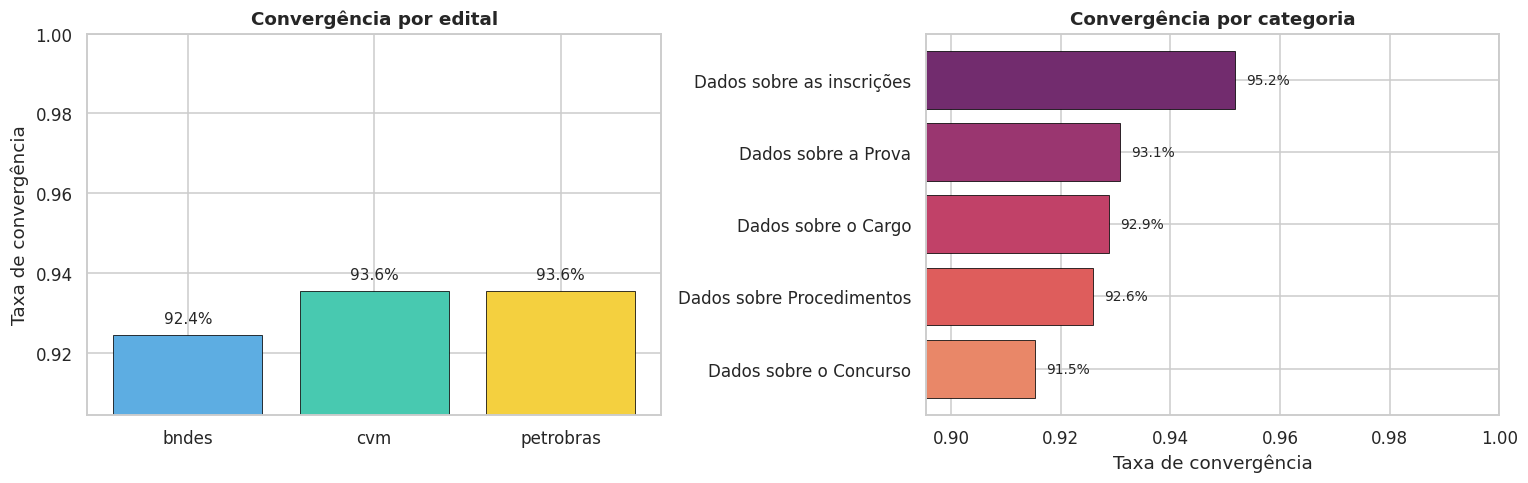

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

conv_ed = df_av.groupby("edital")["convergencia"].mean().sort_values()
axes[0].bar(conv_ed.index, conv_ed.values,
            color=["#5DADE2","#48C9B0","#F4D03F"], edgecolor="black", linewidth=0.5)
axes[0].set_title("Convergência por edital")
axes[0].set_ylabel("Taxa de convergência")
axes[0].set_ylim(conv_ed.min() - 0.02, 1.0)
for i, v in enumerate(conv_ed.values):
    axes[0].text(i, v + 0.003, f"{v:.1%}", ha="center", fontsize=10)

conv_cat = df_av.groupby("categoria")["convergencia"].mean().sort_values()
axes[1].barh(conv_cat.index, conv_cat.values,
             color=sns.color_palette("flare", n_colors=len(conv_cat)),
             edgecolor="black", linewidth=0.5)
axes[1].set_title("Convergência por categoria")
axes[1].set_xlabel("Taxa de convergência")
axes[1].set_xlim(conv_cat.min() - 0.02, 1.0)
for i, v in enumerate(conv_cat.values):
    axes[1].text(v + 0.002, i, f"{v:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## 5. Desempenho por Modelo

### 5.1 Ranking — Avaliação Final vs Nota de Consenso

In [14]:
ranking = (
    df_av.groupby(["modelo","provedor"]).agg(
        nota_gpt=("avaliacao_gpt","mean"),
        nota_opus=("avaliacao_opus","mean"),
        nota_consenso=("nota_consenso","mean"),
        avaliacao_final=("avaliacao_final","mean"),
        convergencia=("convergencia","mean"),
        n_divergencias=("convergencia", lambda x: (~x).sum()),
        n=("id","count"),
    )
    .reset_index()
    .sort_values("avaliacao_final", ascending=False)
    .reset_index(drop=True)
)
ranking.index += 1
ranking.index.name = "rank"
ranking.round(4)


,modelo,provedor,nota_gpt,nota_opus,nota_consenso,avaliacao_final,convergencia,n_divergencias,n
rank,,,,,,,,,
1,gpt-5.5,openai,0.9833,1.0000,0.9917,0.9967,0.9667,5,150
2,claude-opus-4-7,anthropic,0.9700,0.9967,0.9833,0.9767,0.9467,8,150
3,claude-sonnet-4-6,anthropic,0.9667,0.9933,0.9800,0.9733,0.9467,8,150
4,deepseek-v4-flash,deepseek,0.9633,0.9900,0.9767,0.9700,0.9467,8,150
5,deepseek-v4-pro,deepseek,0.9433,0.9867,0.9650,0.9633,0.9133,13,150
6,gpt-5.4,openai,0.9667,0.9600,0.9633,0.9633,0.9867,2,150
7,claude-haiku-4-5,anthropic,0.9267,0.9833,0.9550,0.9367,0.8867,17,150
8,gpt-4o-mini,openai,0.9033,0.9467,0.9250,0.9100,0.9000,15,150
9,gpt-5.4-mini,openai,0.8967,0.9300,0.9133,0.9067,0.8933,16,150


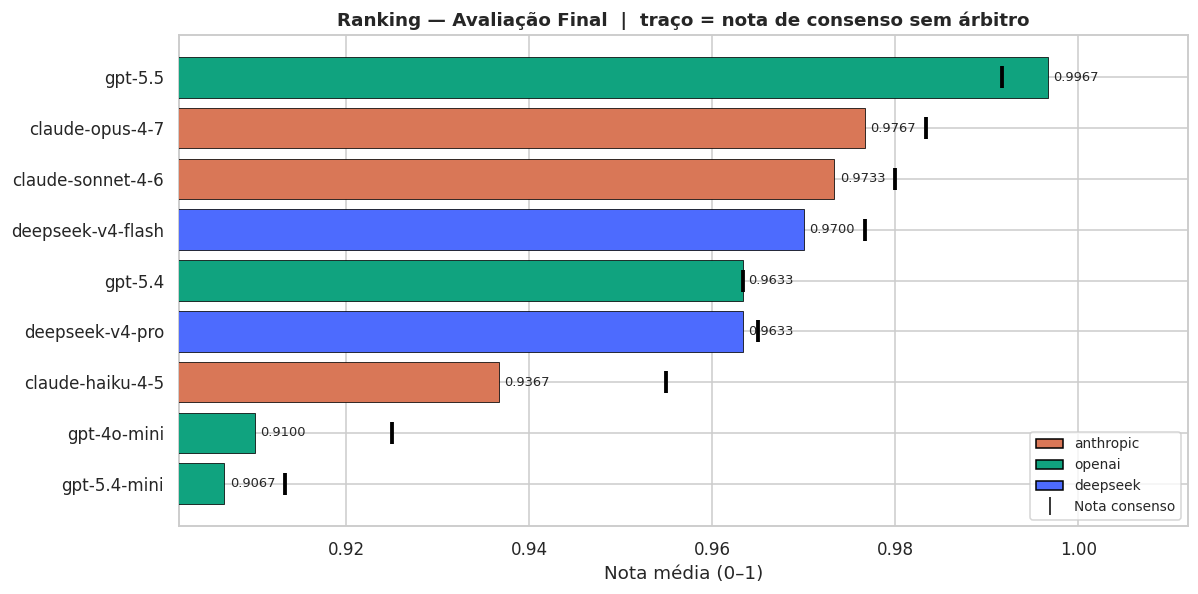

In [15]:
fig, ax = plt.subplots(figsize=(11, 5.5))
df_plot = ranking.sort_values("avaliacao_final", ascending=True)
cores = [PALETA_PROVEDOR[p] for p in df_plot["provedor"]]

bars = ax.barh(df_plot["modelo"], df_plot["avaliacao_final"],
               color=cores, edgecolor="black", linewidth=0.5, label="Avaliação Final", zorder=3)

# marcador: nota consenso simples
ax.scatter(df_plot["nota_consenso"], df_plot["modelo"],
           color="black", marker="|", s=200, linewidths=2.5, zorder=4,
           label="Nota de consenso (sem árbitro)")

xmin = min(df_plot[["avaliacao_final","nota_consenso"]].min()) - 0.005
ax.set_xlim(xmin, 1.012)
ax.set_xlabel("Nota média (0–1)")
ax.set_title("Ranking — Avaliação Final  |  traço = nota de consenso sem árbitro")

for bar, val in zip(bars, df_plot["avaliacao_final"]):
    ax.text(val + 0.0006, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8.5)

legend_prov = [mpatches.Patch(facecolor=c, edgecolor="black", label=p)
               for p, c in PALETA_PROVEDOR.items()]
ax.legend(handles=legend_prov + [
    plt.Line2D([0],[0], marker="|", color="black", markersize=12,
               linewidth=0, label="Nota consenso")
], loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


### 5.2 GPT × Opus × Final por modelo

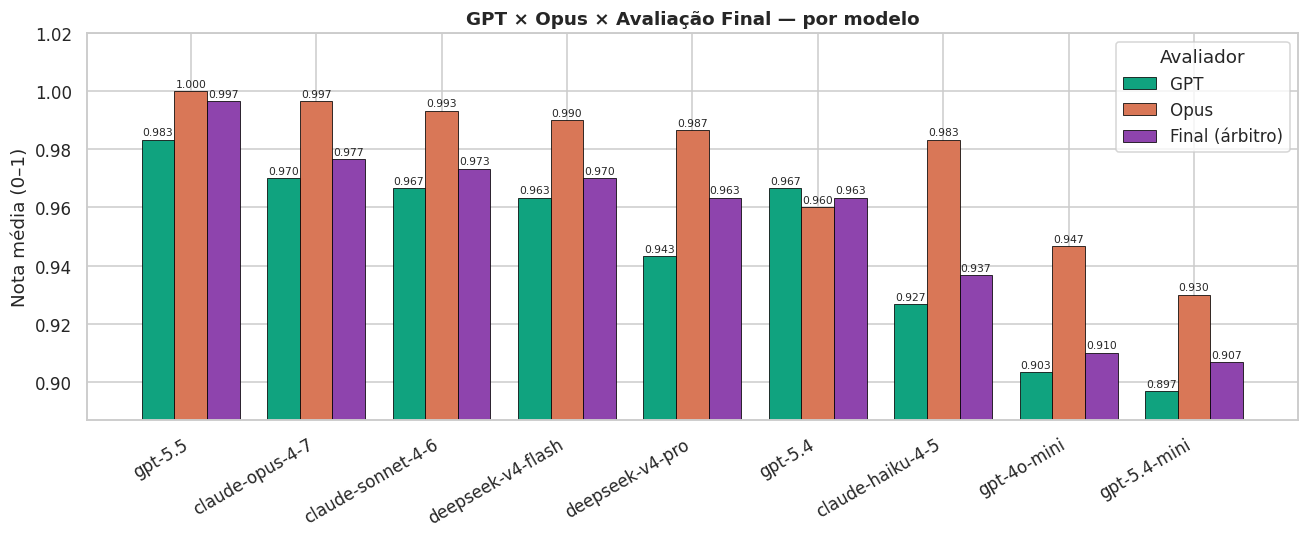

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ranking))
w = 0.26

df_ord = ranking.sort_values("avaliacao_final", ascending=False)

b1 = ax.bar(x - w, df_ord["nota_gpt"],       w, label="GPT",
            color=PALETA_AVALIADOR["gpt"],   edgecolor="black", linewidth=0.5)
b2 = ax.bar(x,     df_ord["nota_opus"],      w, label="Opus",
            color=PALETA_AVALIADOR["opus"],  edgecolor="black", linewidth=0.5)
b3 = ax.bar(x + w, df_ord["avaliacao_final"],w, label="Final (árbitro)",
            color=PALETA_AVALIADOR["humano"],edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(df_ord["modelo"], rotation=30, ha="right")
ax.set_ylabel("Nota média (0–1)")
ax.set_title("GPT × Opus × Avaliação Final — por modelo")
vmin = df_ord[["nota_gpt","nota_opus","avaliacao_final"]].min().min() - 0.01
ax.set_ylim(vmin, 1.02)
ax.legend(title="Avaliador")

for bs in [b1, b2, b3]:
    for bar in bs:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.0008,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.show()


## 6. Desempenho por Edital

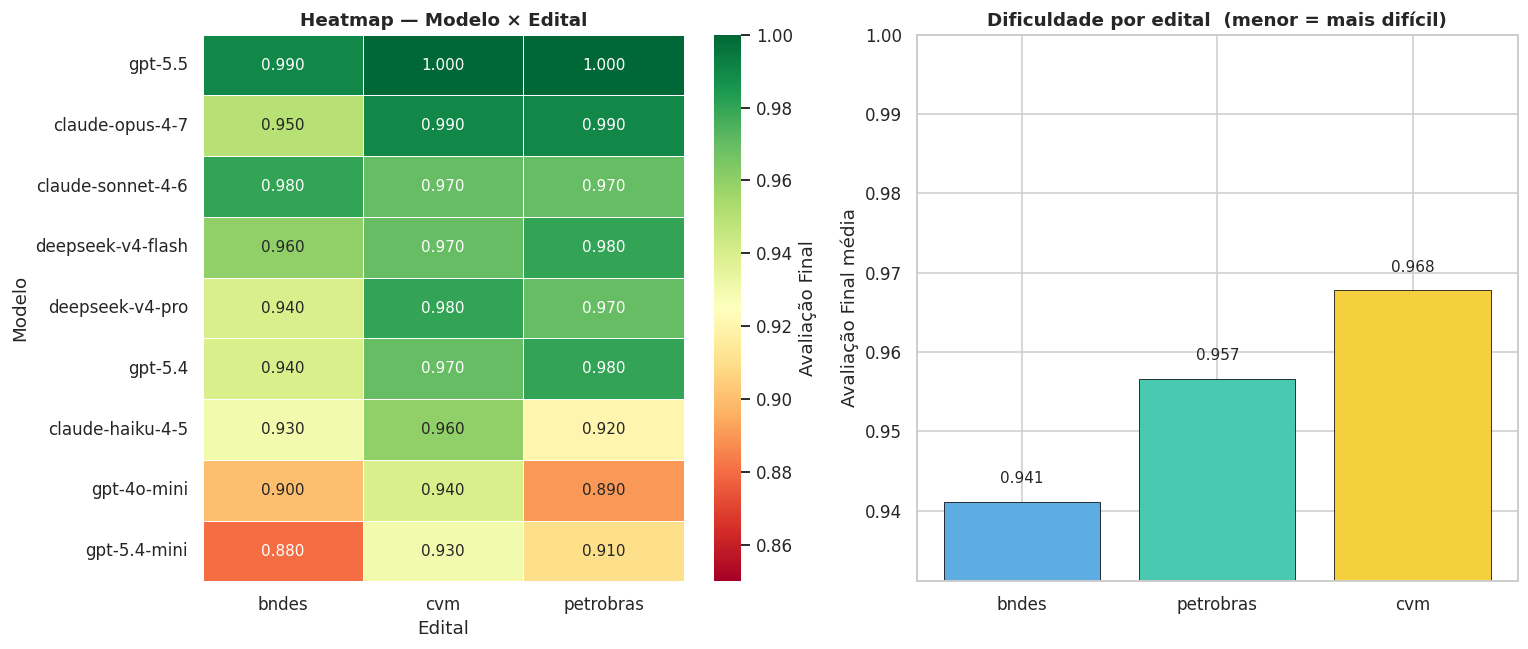

In [17]:
heat = df_av.groupby(["modelo","edital"])["avaliacao_final"].mean().unstack()
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(heat, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.85, vmax=1.0,
            cbar_kws={"label":"Avaliação Final"}, linewidths=0.5, ax=axes[0])
axes[0].set_title("Heatmap — Modelo × Edital")
axes[0].set_xlabel("Edital")
axes[0].set_ylabel("Modelo")

medias = df_av.groupby("edital")["avaliacao_final"].mean().sort_values()
bars = axes[1].bar(medias.index, medias.values,
                   color=["#5DADE2","#48C9B0","#F4D03F"], edgecolor="black", linewidth=0.5)
axes[1].set_ylabel("Avaliação Final média")
axes[1].set_title("Dificuldade por edital  (menor = mais difícil)")
axes[1].set_ylim(medias.min() - 0.01, 1.0)
for bar, v in zip(bars, medias.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.002,
                 f"{v:.3f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


## 7. Desempenho por Categoria

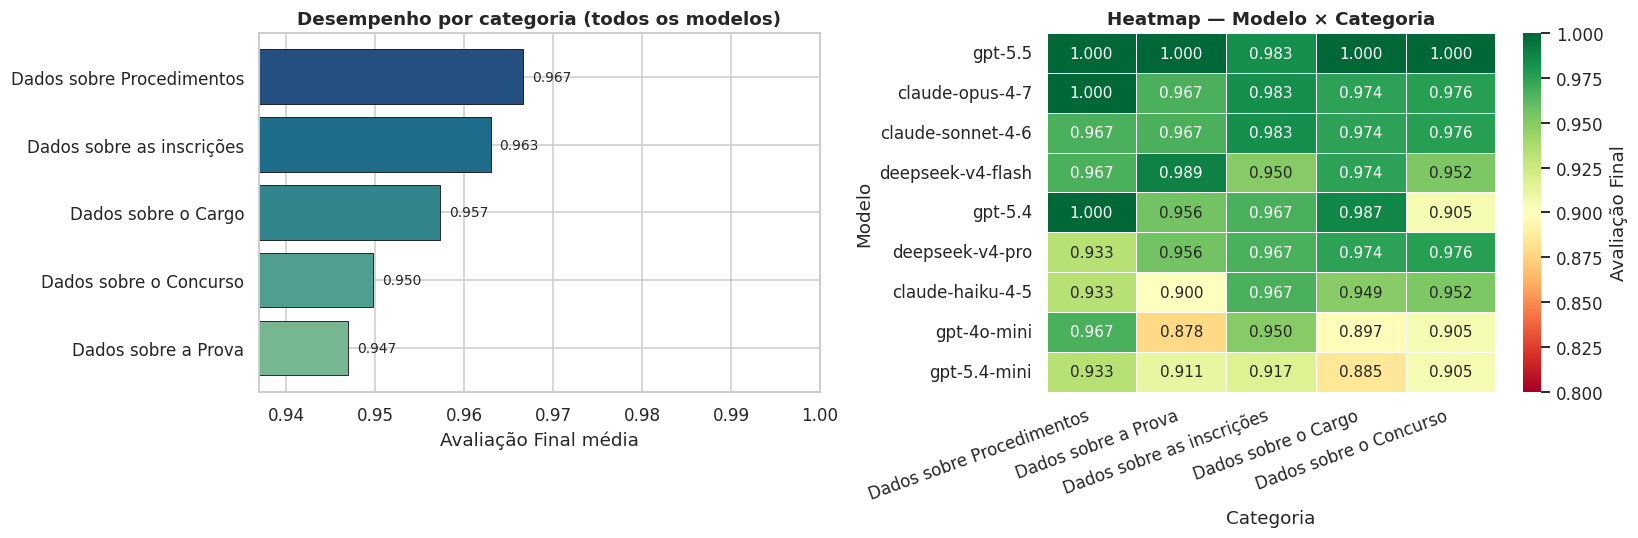

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cat_perf = df_av.groupby("categoria")["avaliacao_final"].mean().sort_values()
bars = axes[0].barh(cat_perf.index, cat_perf.values,
                    color=sns.color_palette("crest", n_colors=len(cat_perf)),
                    edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Avaliação Final média")
axes[0].set_title("Desempenho por categoria (todos os modelos)")
axes[0].set_xlim(cat_perf.min() - 0.01, 1.0)
for bar, v in zip(bars, cat_perf.values):
    axes[0].text(v + 0.001, bar.get_y() + bar.get_height()/2,
                 f"{v:.3f}", va="center", fontsize=9)

heat_cat = df_av.groupby(["modelo","categoria"])["avaliacao_final"].mean().unstack()
heat_cat = heat_cat.loc[heat_cat.mean(axis=1).sort_values(ascending=False).index]
sns.heatmap(heat_cat, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.80, vmax=1.0,
            cbar_kws={"label":"Avaliação Final"}, linewidths=0.5, ax=axes[1])
axes[1].set_title("Heatmap — Modelo × Categoria")
axes[1].set_xlabel("Categoria")
axes[1].set_ylabel("Modelo")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()


## 8. Métricas Operacionais

In [19]:
# Uma linha por pergunta/modelo (evitar duplicação dos 2 avaliadores)
df_op = df_me[df_me["avaliador"] == "gpt"].copy()
print(f"Amostra operacional: {len(df_op)} linhas")


Amostra operacional: 1350 linhas


### 8.1 Latência

/tmp/ipykernel_68231/1951381665.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


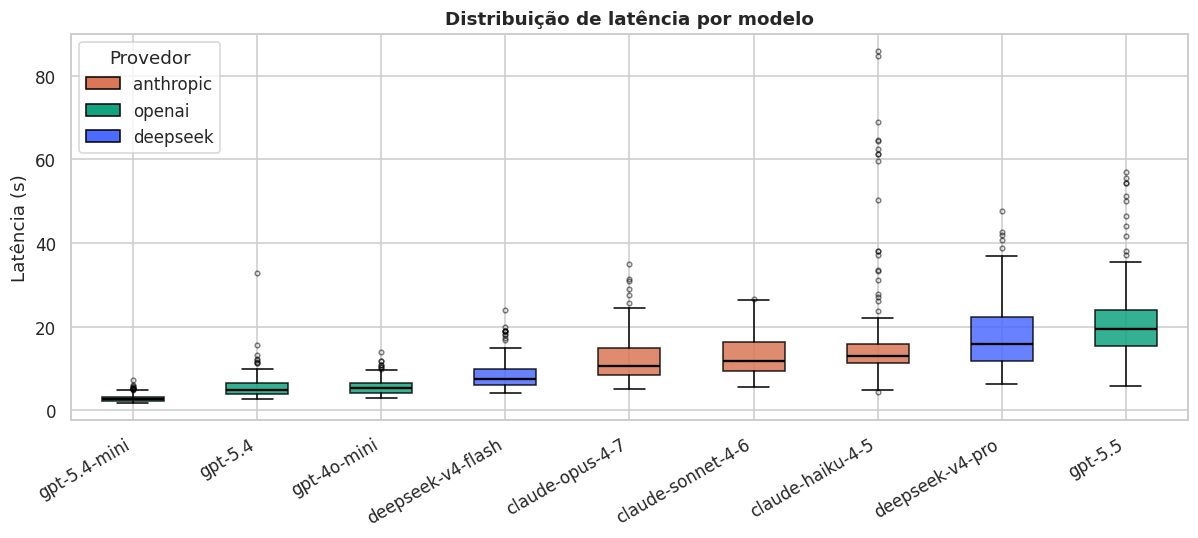


Latência mediana (s):
modelo
gpt-5.4-mini          2.66
gpt-5.4               4.89
gpt-4o-mini           5.20
deepseek-v4-flash     7.50
claude-opus-4-7      10.62
claude-sonnet-4-6    11.68
claude-haiku-4-5     12.96
deepseek-v4-pro      15.85
gpt-5.5              19.50


In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
ordem_lat = df_op.groupby("modelo")["latencia_s"].median().sort_values().index
cores_box = [PALETA_PROVEDOR[df_op[df_op["modelo"]==m]["provedor"].iloc[0]]
             for m in ordem_lat]

box = ax.boxplot(
    [df_op[df_op["modelo"]==m]["latencia_s"].values for m in ordem_lat],
    labels=ordem_lat, patch_artist=True, showfliers=True,
    medianprops={"color":"black","linewidth":1.5},
    flierprops={"marker":"o","markersize":3,"alpha":0.5},
)
for patch, color in zip(box["boxes"], cores_box):
    patch.set_facecolor(color); patch.set_edgecolor("black"); patch.set_alpha(0.85)

ax.set_ylabel("Latência (s)")
ax.set_title("Distribuição de latência por modelo")
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), ha="right")
legend = [mpatches.Patch(facecolor=c, edgecolor="black", label=p)
          for p, c in PALETA_PROVEDOR.items()]
ax.legend(handles=legend, title="Provedor", loc="upper left")
plt.tight_layout()
plt.show()

print("\nLatência mediana (s):")
print(df_op.groupby("modelo")["latencia_s"].median().sort_values().round(2).to_string())


### 8.2 Tokens de saída e invocações

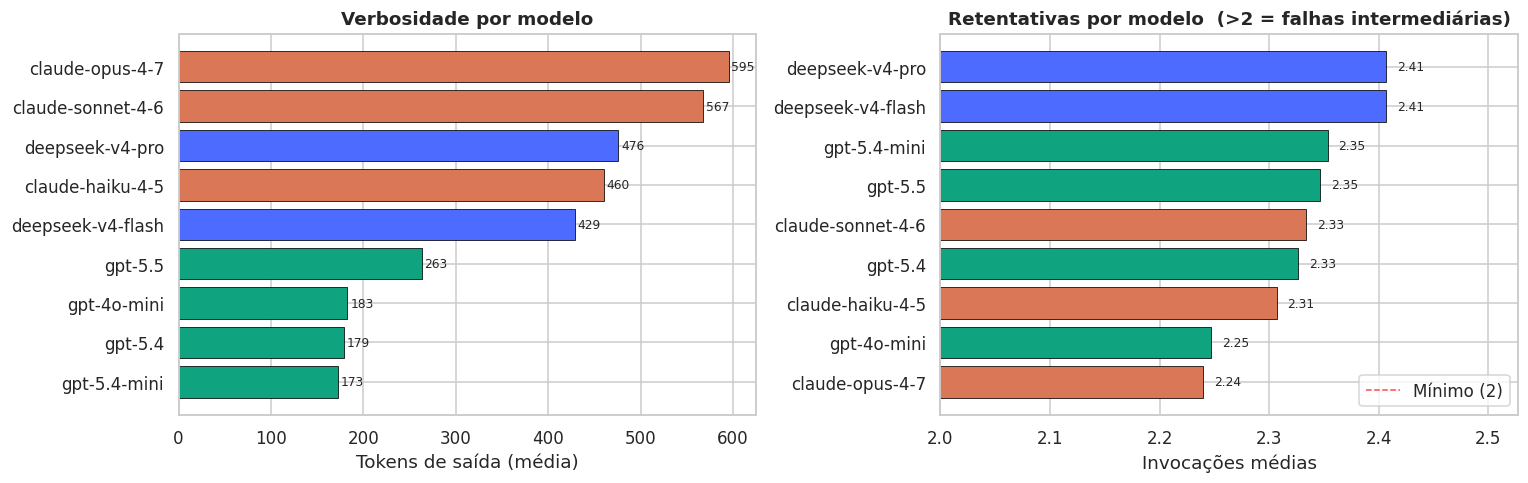

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

out_avg = (df_op.groupby(["modelo","provedor"])["output_tokens"]
           .mean().reset_index().sort_values("output_tokens"))
cores_t = [PALETA_PROVEDOR[p] for p in out_avg["provedor"]]
axes[0].barh(out_avg["modelo"], out_avg["output_tokens"],
             color=cores_t, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Tokens de saída (média)")
axes[0].set_title("Verbosidade por modelo")
for bar, v in zip(axes[0].patches, out_avg["output_tokens"]):
    axes[0].text(v + 3, bar.get_y() + bar.get_height()/2,
                 f"{v:.0f}", va="center", fontsize=8)

inv_mod = df_op.groupby("modelo")["n_invocacoes"].mean().sort_values()
cores_inv = [PALETA_PROVEDOR[df_op[df_op["modelo"]==m]["provedor"].iloc[0]]
             for m in inv_mod.index]
axes[1].barh(inv_mod.index, inv_mod.values,
             color=cores_inv, edgecolor="black", linewidth=0.5)
axes[1].axvline(2, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Mínimo (2)")
axes[1].set_xlabel("Invocações médias")
axes[1].set_title("Retentativas por modelo  (>2 = falhas intermediárias)")
axes[1].set_xlim(2, inv_mod.max() * 1.05)
axes[1].legend(loc="lower right")
for i, v in enumerate(inv_mod.values):
    axes[1].text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()


## 9. Trade-off Qualidade × Latência

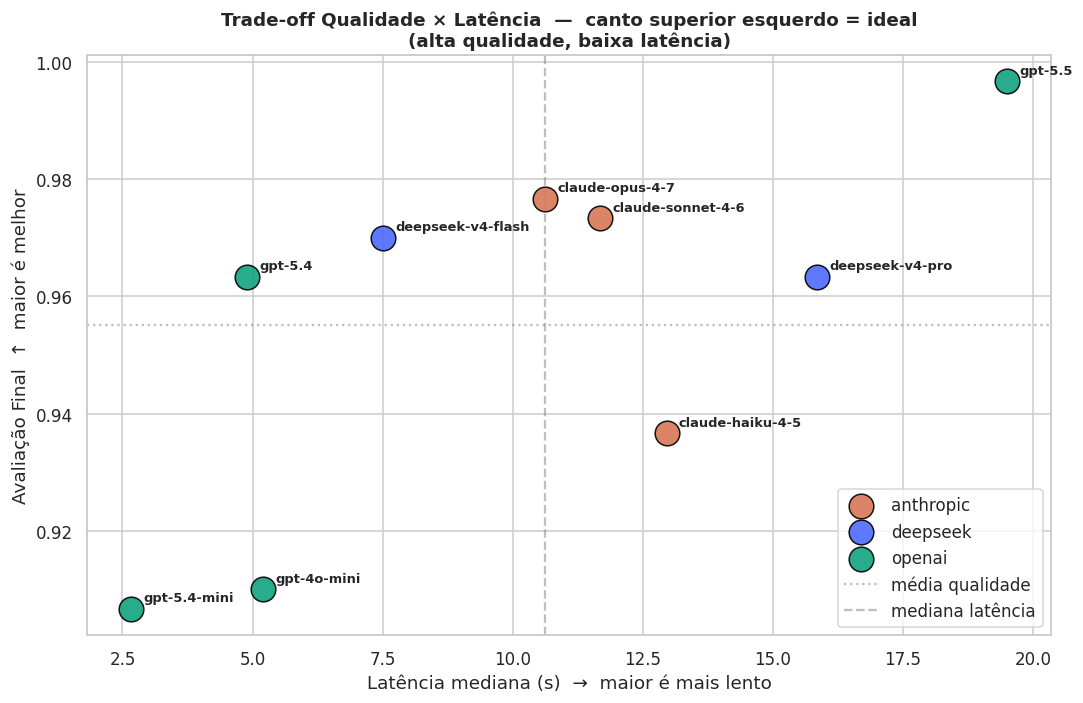

In [23]:
qual  = df_av.groupby("modelo")["avaliacao_final"].mean().rename("nota")
lat   = df_op.groupby("modelo")["latencia_s"].median().rename("latencia")
prov  = df_av.groupby("modelo")["provedor"].first()
trade = pd.concat([qual, lat, prov], axis=1).reset_index()

fig, ax = plt.subplots(figsize=(10, 6.5))
for pv, grupo in trade.groupby("provedor"):
    ax.scatter(grupo["latencia"], grupo["nota"],
               color=PALETA_PROVEDOR[pv], s=260, edgecolor="black",
               linewidth=1.0, label=pv, alpha=0.9, zorder=3)
for _, r in trade.iterrows():
    ax.annotate(r["modelo"], (r["latencia"], r["nota"]),
                xytext=(8, 5), textcoords="offset points",
                fontsize=8.5, fontweight="bold")

ax.axhline(trade["nota"].mean(),       color="gray", linestyle=":",  alpha=0.5, label="média qualidade")
ax.axvline(trade["latencia"].median(), color="gray", linestyle="--", alpha=0.5, label="mediana latência")

ax.set_xlabel("Latência mediana (s)  →  maior é mais lento")
ax.set_ylabel("Avaliação Final  ↑  maior é melhor")
ax.set_title("Trade-off Qualidade × Latência  —  canto superior esquerdo = ideal\n(alta qualidade, baixa latência)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. Análise por Provedor

In [25]:
prov_stats = (
    df_av.groupby("provedor").agg(
        avaliacao_final=("avaliacao_final","mean"),
        nota_consenso=("nota_consenso","mean"),
        convergencia=("convergencia","mean"),
    )
    .merge(df_op.groupby("provedor").agg(
        latencia_mediana=("latencia_s","median"),
        output_tokens=("output_tokens","mean"),
        n_invocacoes=("n_invocacoes","mean"),
    ), on="provedor")
    .reset_index()
    .sort_values("avaliacao_final", ascending=False)
)
prov_stats.round(4)


,provedor,avaliacao_final,nota_consenso,convergencia,latencia_mediana,output_tokens,n_invocacoes
1,deepseek,0.9667,0.9708,0.9300,10.880,452.3767,2.4067
0,anthropic,0.9622,0.9728,0.9267,11.980,540.9533,2.2933
2,openai,0.9442,0.9483,0.9367,5.175,199.3267,2.3183


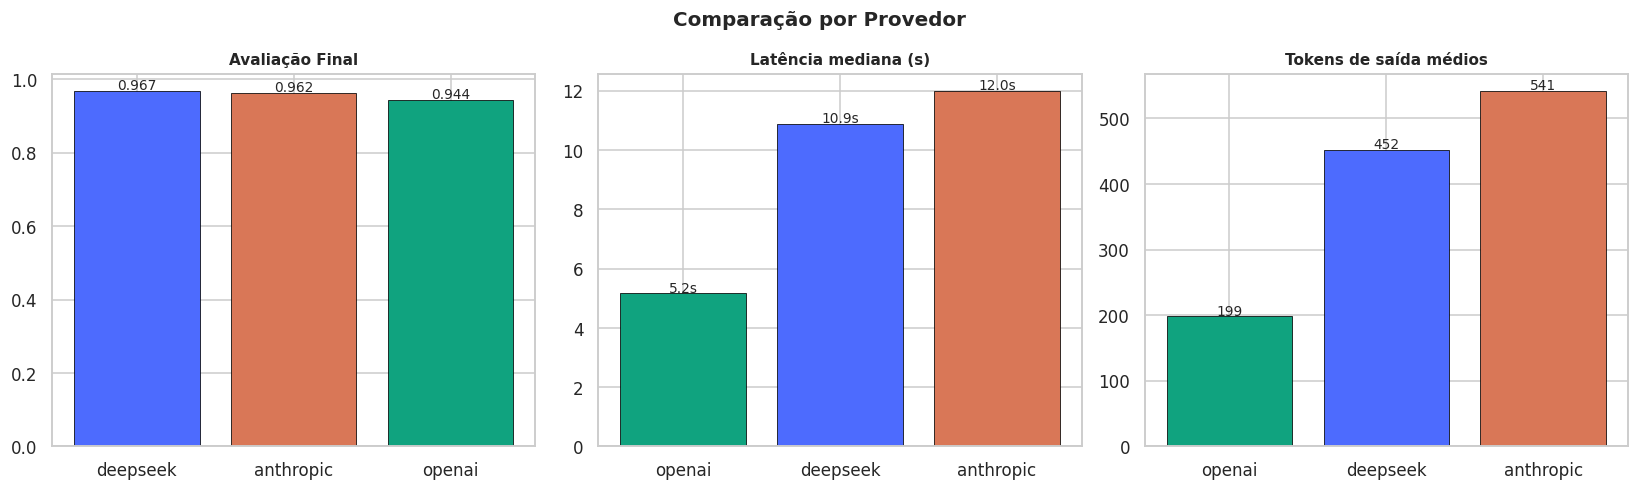

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, titulo, fmt in zip(
    axes,
    ["avaliacao_final","latencia_mediana","output_tokens"],
    ["Avaliação Final","Latência mediana (s)","Tokens de saída médios"],
    ["{:.3f}","{:.1f}s","{:.0f}"],
):
    df_p = prov_stats.sort_values(col, ascending=(col!="avaliacao_final"))
    cores_p = [PALETA_PROVEDOR[p] for p in df_p["provedor"]]
    bars = ax.bar(df_p["provedor"], df_p[col], color=cores_p,
                  edgecolor="black", linewidth=0.5)
    ax.set_title(titulo, fontsize=10)
    for i, v in enumerate(df_p[col]):
        ax.text(i, v * 1.005, fmt.format(v), ha="center", fontsize=9)

plt.suptitle("Comparação por Provedor", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 11. Ranking Final Consolidado

In [27]:
ranking_final = (
    df_av.groupby(["modelo","provedor"]).agg(
        avaliacao_final=("avaliacao_final","mean"),
        nota_consenso=("nota_consenso","mean"),
        convergencia=("convergencia","mean"),
        n_divergencias=("convergencia", lambda x: (~x).sum()),
    )
    .merge(df_op.groupby("modelo").agg(
        latencia_mediana=("latencia_s","median"),
        output_tokens=("output_tokens","mean"),
        n_invocacoes=("n_invocacoes","mean"),
    ), on="modelo")
    .reset_index()
    .sort_values("avaliacao_final", ascending=False)
    .reset_index(drop=True)
)
ranking_final.index += 1
ranking_final.index.name = "rank"

(ranking_final.style
 .background_gradient(subset=["avaliacao_final"], cmap="RdYlGn", vmin=0.90, vmax=1.0)
 .background_gradient(subset=["nota_consenso"],   cmap="RdYlGn", vmin=0.90, vmax=1.0)
 .background_gradient(subset=["convergencia"],    cmap="Blues",  vmin=0.85, vmax=1.0)
 .background_gradient(subset=["latencia_mediana"],cmap="RdYlGn_r")
 .background_gradient(subset=["output_tokens"],   cmap="Oranges")
 .format({
     "avaliacao_final":  "{:.4f}",
     "nota_consenso":    "{:.4f}",
     "convergencia":     "{:.1%}",
     "n_divergencias":   "{:.0f}",
     "latencia_mediana": "{:.2f}s",
     "output_tokens":    "{:.0f}",
     "n_invocacoes":     "{:.2f}",
 })
)


,modelo,avaliacao_final,nota_consenso,convergencia,n_divergencias,latencia_mediana,output_tokens,n_invocacoes
rank,,,,,,,,
1,gpt-5.5,0.9967,0.9917,96.7%,5,19.50s,263,2.35
2,claude-opus-4-7,0.9767,0.9833,94.7%,8,10.62s,595,2.24
3,claude-sonnet-4-6,0.9733,0.9800,94.7%,8,11.68s,567,2.33
4,deepseek-v4-flash,0.9700,0.9767,94.7%,8,7.50s,429,2.41
5,deepseek-v4-pro,0.9633,0.9650,91.3%,13,15.85s,476,2.41
6,gpt-5.4,0.9633,0.9633,98.7%,2,4.89s,179,2.33
7,claude-haiku-4-5,0.9367,0.9550,88.7%,17,12.96s,460,2.31
8,gpt-4o-mini,0.9100,0.9250,90.0%,15,5.20s,183,2.25
9,gpt-5.4-mini,0.9067,0.9133,89.3%,16,2.67s,173,2.35
